In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.miscellaneous as mi
import src.figure as fi
import src.blinking as bl
import experimental_data_analysis as eda

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
exp_data = eda.ExperimentalData(file=r"C:\Users\ebert\Desktop\Fluorocubes_AF647_widefield_dSTORM\Fluorocubes_4x_fingerprint\4xAF647_5ms_120kfr_Epi_EMCCD_crop_f7,5_400mw_256x256px_quad_line-PFS_0.txt")
exp_data.data

,x_position,x_uncertain,y_position,y_uncertain,frame,intensity,fit,background
0,32454.200,25,28502.000,25,0,18619.80,1415690.0,743.458
1,28274.900,25,382.353,25,0,17068.60,2069070.0,743.013
2,24269.800,25,25233.600,25,0,15101.00,5335530.0,860.656
3,30218.500,25,9715.340,25,0,14681.40,5915150.0,896.372
4,20959.700,25,24261.600,25,0,13535.90,3646630.0,844.480
...,...,...,...,...,...,...,...,...
88580,720.425,25,153.994,25,119995,2035.72,428864.0,567.140
88581,647.667,25,261.269,25,119997,1757.21,266692.0,560.247
88582,668.244,25,219.778,25,119998,2728.19,285103.0,541.172
88583,691.734,25,215.213,25,119999,4366.00,340677.0,578.126


In [3]:
exp_data.cluster(eps=25, min_samples=3)

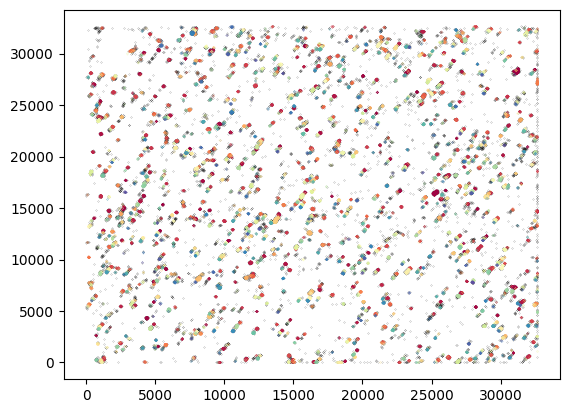

In [4]:
exp_data.plot_cluster()

### Detailed view

119999
[0.00000000e+00 5.00004167e-03 1.00000833e-02 ... 5.99985000e+02
 5.99990000e+02 5.99995000e+02]
599.995


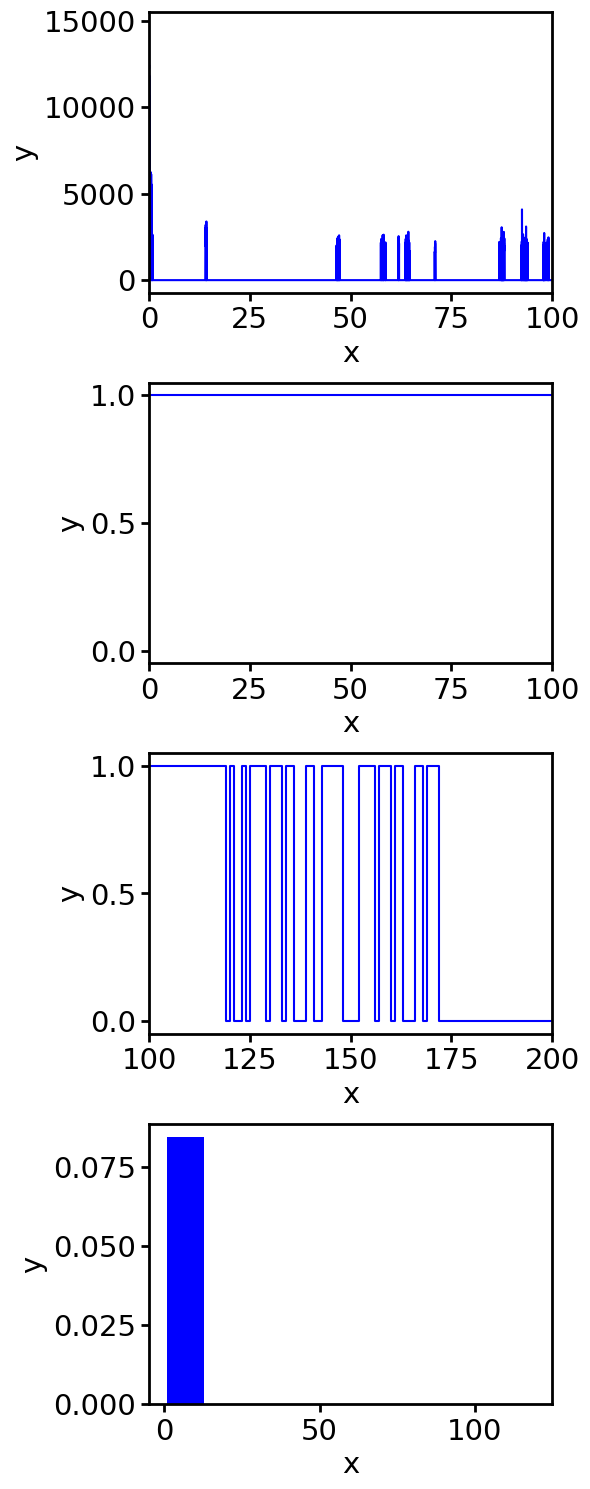

In [10]:
event_time_series = exp_data.get_event_time_series(4, '5ms')
on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)

# plot it
axes = fi.universal_figure(nrows=4, fig_height=15)
fi.universal_figure(axes=axes[0], type_='line', data=[event_time_series.index, event_time_series.values], xlim=[0, 100])
fi.universal_figure(axes=axes[1], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100])
fi.universal_figure(axes=axes[2], type_='line', data=[on_off_frames, on_off_values], xlim=[100, 200])
fi.universal_figure(axes=axes[3], type_='hist', data=on_periods, density=True)
fig = mi.get_figure(axes)
fig.tight_layout()
        

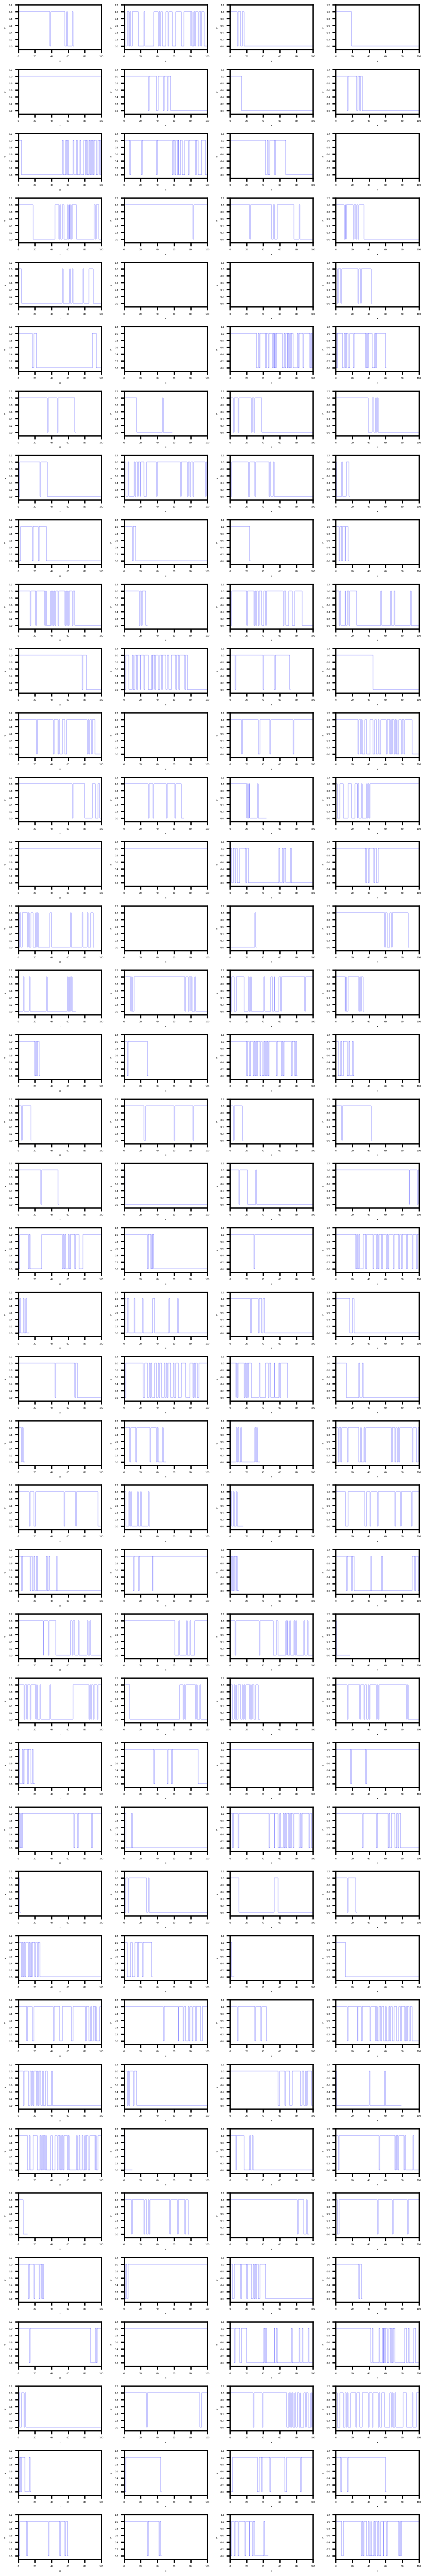

In [33]:
nrows = 40
ncols = 4


axes = fi.universal_figure(nrows=nrows, ncols=ncols, fig_height=nrows*1.5, fig_width=10)
j = 0
h = 0
for i in np.arange(0, nrows*ncols, 1):
    if j > ncols-1:
        h += 1
        j = 0
    event_time_series = exp_data.get_event_series(i)
    on_periods, off_periods, on_frames, off_frames = bl.get_blinking_statistics(event_time_series)
    on_off_frames, on_off_values = bl.get_analytical_off_statistics(off_frames, off_periods)
    # fi.universal_figure(axes=axes[h, j], type_='line', data=[event_time_series.index, event_time_series.values], 
    #                     xlim=[0, 100], fontsize=4, lw=0.3)
    fi.universal_figure(axes=axes[h, j], type_='line', data=[on_off_frames, on_off_values], xlim=[0, 100],
                        fontsize=4, lw=0.3, ylim=[-0.1, 1.2])
    j += 1
fig = mi.get_figure(axes)
fig.tight_layout()